In [1]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(os.path.abspath("/home/anushkasingh/Desktop/Thesis/Code/Baseline Correction"))
from load_data import read_data, create_combined_dataset
from baseline_correct import baseline_roy

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


from scipy.stats import f_oneway
import seaborn as sns


In [2]:
path = ["../ALLDataGross/allKgData",
    "../ALLDataGross/BlindData",
    "../ALLDataGross/healthyCohort"
]
normVP = [[504, 425, 451, 454, 450, 474, 451, 471, 540, 467,
    550, 468, 481, 450, 515, 441, 452, 462, 453, 450, 452, 
    490, 504, 520, 525, 498, 542, 527, 550],
        [505, 503, 478, 453, 460, 494, 410, 413, 479, 489, 
    473, 464, 445, 499, 406, 455, 481, 388, 428, 466, 463, 
    520, 461],
    [420, 420, 428, 448, 417, 430, 420, 449, 483, 499, 
    438, 465, 438, 428, 503, 505, 504, 454, 515, 441, 
    404, 363]]
infoP = [["H", "PC", "PC", "H", "PC", "BC", "PC", "PC", "BC", "BC", 
    "PC", "PC", "PC", "PC", "H", "H","PC", "PC", "KC", "PC", "KC", 
    "PC", "BC", "BC", "PC", "KC", "PC", "PC", "PC"],
        ["H", "H" ,"H" ,"H", "KG", "KG", "KG", "KG", "KG", "KG", "KG", "KG", "KG" ,
     "KG", "KG", "KG", "KG", "KG" ,"KG", "KG" ,"KG", "KG", "KG"],
          ["F", "M", "M", "F", "F", "F", "F", "M", "M", "M", 
    "M", "F", "M", "M", "F", "M" ,"M", "M", "M", "M", 
    "M", "M" ]
]
df = create_combined_dataset(path,normVP,infoP)

df['intensity_baseline_corrected'] = None
for idx, row in df.iterrows():
    df.at[idx, "intensity_baseline_corrected"] = baseline_roy(x=row["wavenumber"], y=row["intensity"], norm_factor_i=row['normVP'])
    print(f"{idx} done!")
print("baseline corrected!")

Folder exists: True
Folder contents: [PosixPath('../ALLDataGross/allKgData/20190801-02-023.dpt'), PosixPath('../ALLDataGross/allKgData/dataLoadKGall.m'), PosixPath('../ALLDataGross/allKgData/20190801-01-022.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-04-012.dpt'), PosixPath('../ALLDataGross/allKgData/20190801-03-024.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-05-004.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-12-010.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-10-018.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-05-013.dpt'), PosixPath('../ALLDataGross/allKgData/20190801-07-028.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-04-003.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-09-017.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-03-002.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-06-014.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-02-001.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-13-021.dpt'), PosixP

In [3]:
df = df[df["category"]!= "blinddata"]
df["category"].unique()

array(['allkgdata', 'healthydata'], dtype=object)

In [4]:
SRs = [1005, 530, 1050, 1190, 1203, 1170, 2170]
SRdict = {f"SR_{sr}": (sr-15, sr+15) for sr in SRs}
SRdict

{'SR_1005': (990, 1020),
 'SR_530': (515, 545),
 'SR_1050': (1035, 1065),
 'SR_1190': (1175, 1205),
 'SR_1203': (1188, 1218),
 'SR_1170': (1155, 1185),
 'SR_2170': (2155, 2185)}

In [5]:
SRlist = [1005, 530, 1050, 1190, 1203, 1170, 2170]
SRs = {f"SR_{sr}": (sr-15, sr+15) for sr in SRlist}


df = df[df['infoP'].isin(["PC", "M", "F", "H", "KC", "BC"])]
df["class"] = df["infoP"].apply(lambda x: "Healthy" if x in ["M", "F", "H"] else x)

def extract_sr_matrix(df, start, end):
    # Find indices once for the first row
    wn = df.iloc[0]['wavenumber']
    mask = (wn >= start) & (wn <= end)
    return np.stack(df['intensity'].apply(lambda x: x[mask]).values)

SR_matrices = {}
for name, (s,e) in SRs.items():
    SR_matrices[name] = extract_sr_matrix(df, s, e)


print("(rows = patients, cols = spectral points)")
# for k in SR_matrices.keys():
#     print(f"shape of matrix corresponding to {k} : {SR_matrices[k].shape}")

(rows = patients, cols = spectral points)


In [6]:
# pca_results = {}
# for name, mat in SR_matrices.items():
#     # SR wise PCA.
#     # print("before standard scaler")
#     # print("Feature means:", mat.mean(axis=0)[:5])
#     # print("Feature stds:", mat.std(axis=0)[:5])

# # 3. Apply proper scaling BEFORE PCA

#     scaler = StandardScaler()
#     mat = scaler.fit_transform(mat)  # Mean=0, Std=1 per feature
#     # FEATURE WISE NORMALIZATION
#     # print("after standard scaler")
#     # print("Feature means:", mat.mean(axis=0)[:5])
#     # print("Feature stds:", mat.std(axis=0)[:5])
#     numPcs = 4
#     pca = PCA(n_components=numPcs)   # same as paper up to PC4
#     pcs = pca.fit_transform(mat)
#     pca_results[name] = pcs

# result_df = df[['patient_id','infoP']].copy()
# for name, pcs in pca_results.items():
#     for n in range(numPcs):
#         result_df[f'{name}_PC{n+1}'] = pcs[:,n]

# result_df = result_df[result_df['infoP'].isin(["PC", "M", "F", "H", "KC", "BC"])]
# result_df["class"] = result_df["infoP"].apply(lambda x: "Healthy" if x in ["M", "F", "H"] else x)
# result_df["class"].unique()




In [7]:
for name, mat in SR_matrices.items():

    mat = mat - mat.mean(axis=0)
    print("Feature means:", mat.mean(axis=0)[:5])
    print("Feature stds:", mat.std(axis=0)[:5])


Feature means: [-1.63268092e-18 -3.06127672e-19  3.19733347e-18 -1.42859580e-18
  7.82326273e-19]
Feature stds: [0.00538086 0.00538561 0.00539852 0.00539616 0.00538645]
Feature means: [-5.44226973e-18  1.76873766e-18  6.39466693e-18  1.45580715e-17
  2.72113486e-19]
Feature stds: [0.01805982 0.01790662 0.01792659 0.01797389 0.01791112]
Feature means: [ 1.25852487e-18 -5.03409950e-18  3.02726254e-18  3.40141858e-20
  7.48312088e-19]
Feature stds: [0.00611096 0.0061243  0.00618442 0.00622431 0.00620281]
Feature means: [-1.42859580e-18 -6.80283716e-19 -3.23134765e-18  4.31980160e-18
  1.87078022e-18]
Feature stds: [0.00557488 0.00555663 0.00554089 0.00553658 0.00554509]
Feature means: [-2.00683696e-18 -3.91163137e-18 -1.02042557e-18  4.65994346e-18
  8.16340459e-19]
Feature stds: [0.00542606 0.00542482 0.00543916 0.00544575 0.00542425]
Feature means: [-4.69395764e-18  1.53063836e-18  7.14297902e-19 -1.63268092e-18
 -3.40141858e-19]
Feature stds: [0.00578149 0.00577622 0.00576217 0.0057576

In [8]:
from sklearn.decomposition import PCA

pca_results = {}
numPcs = 4

for name, mat in SR_matrices.items():

    # 1️⃣ Mean centering ONLY
    # mat = mat - mat.mean(axis=0)

    # 2️⃣ PCA
    pca = PCA(n_components=numPcs, svd_solver='full')
    pcs = pca.fit_transform(mat - mat.mean(axis=0))

    pca_results[name] = pcs
    # pca_results[name] = {
    #     "scores": pcs,
    #     "loadings": pca.components_,
    #     "explained_variance": pca.explained_variance_ratio_
    # }
result_df = df[['patient_id','infoP']].copy()
result_df = result_df[result_df['infoP'].isin(["PC", "M", "F", "H", "KC", "BC"])]
result_df["class"] = result_df["infoP"].apply(lambda x: "Healthy" if x in ["M", "F", "H"] else x)
print(len(pca_results[list(pca_results.keys())[0]]))
print(pca_results.keys())
for name, pcs in pca_results.items():
    for n in range(numPcs):
        result_df[f'{name}_PC{n+1}'] = pcs[:,n]

# result_df = result_df[result_df['infoP'].isin(["PC", "M", "F", "H", "KC", "BC"])]
# result_df["class"] = result_df["infoP"].apply(lambda x: "Healthy" if x in ["M", "F", "H"] else x)
result_df["class"].unique()


51
dict_keys(['SR_1005', 'SR_530', 'SR_1050', 'SR_1190', 'SR_1203', 'SR_1170', 'SR_2170'])


array(['Healthy', 'PC', 'BC', 'KC'], dtype=object)

In [9]:
df["class"].unique()

array(['Healthy', 'PC', 'BC', 'KC'], dtype=object)

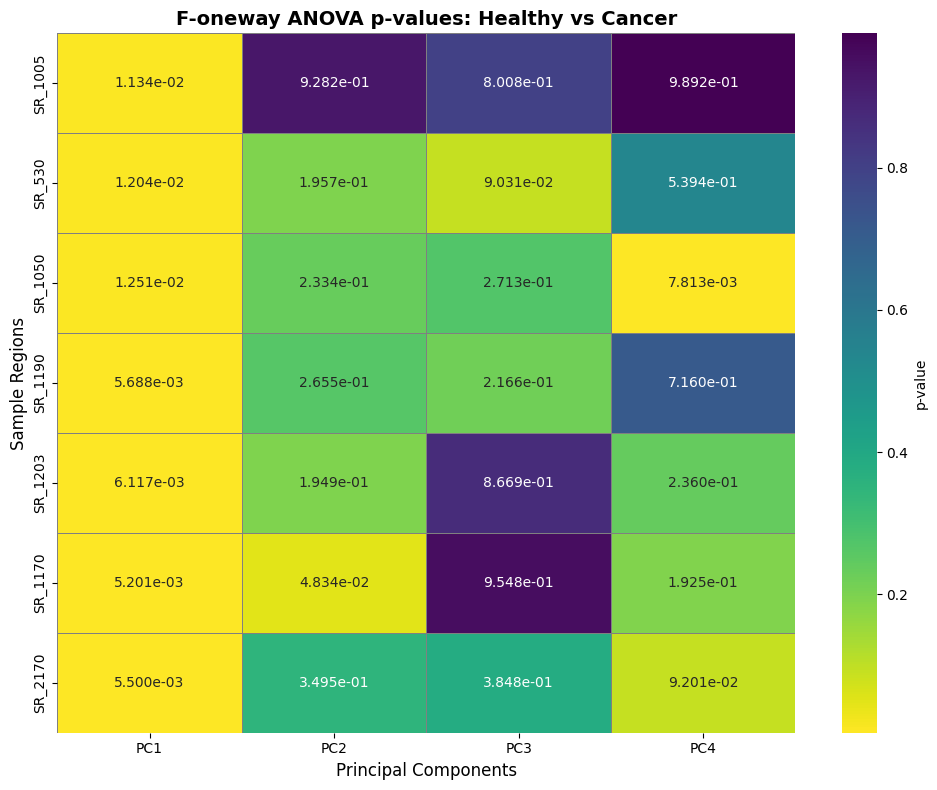

In [10]:
pvalue_matrix = []
for name in SRs.keys():
    row = []
    for pc in [f"PC{n+1}" for n in range(numPcs)]:
        h = result_df[result_df['class']=='Healthy'][f'{name}_{pc}']
        c = result_df[result_df['class'].isin(["PC"])][f'{name}_{pc}']
        # print(name, pc, f_oneway(h,c).pvalue)
        pval = f_oneway(h, c).pvalue
        row.append(pval)
    pvalue_matrix.append(row)

# Convert to DataFrame for better visualization
pvalue_df = pd.DataFrame(
    pvalue_matrix,
    index=list(SRs.keys()),  # Row names
    columns=[f"PC{n+1}" for n in range(numPcs)]  # Column names
)


# Create the heatmap
plt.figure(figsize=(10, 8))
heatmap = sns.heatmap(
    pvalue_df,
    annot=True,           # Show p-values on cells
    fmt=".3e",           # Scientific notation for small p-values
    cmap='viridis_r',    # Reverse viridis (darker = smaller p-value)
    cbar_kws={'label': 'p-value'},
    linewidths=0.5,
    linecolor='gray'
)

plt.title('F-oneway ANOVA p-values: Healthy vs Cancer', fontsize=14, fontweight='bold')
plt.xlabel('Principal Components', fontsize=12)
plt.ylabel('Sample Regions', fontsize=12)
plt.tight_layout()
plt.show()



In [11]:
result_df["class"].value_counts()

class
Healthy    26
PC         17
BC          5
KC          3
Name: count, dtype: int64

['H' 'PC' 'BC' 'KC']


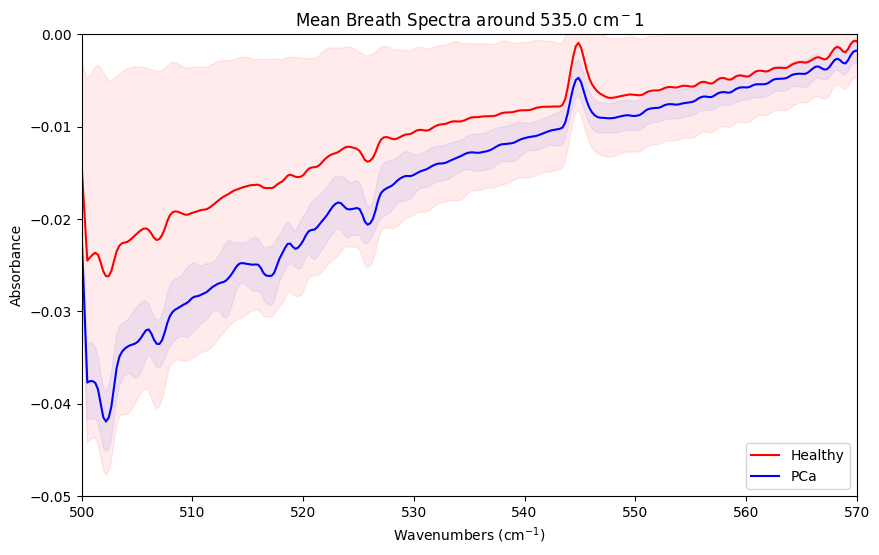

In [12]:
import numpy as np
import matplotlib.pyplot as plt

df = df[df['infoP'].isin(["PC", "M", "F", "H", "KC", "BC"])]
df["class"] = df["infoP"].apply(lambda x: "H" if x in ["M", "F", "H"] else x)
print(df["class"].unique())

# filter groups
healthy = df[df["class"] == "H"]
pca = df[df["class"] == "PC"]

x_lo,x_hi = 500, 570
y_lo, y_hi = -0.05, 0

# stack spectra
original = np.vstack(healthy["intensity_baseline_corrected"].to_numpy())
thirdorder = np.vstack(pca["intensity_baseline_corrected"].to_numpy())

# compute mean and std
H_mean = np.mean(original, axis=0)
H_std = np.std(original, axis=0)

C_mean = np.mean(thirdorder, axis=0)
C_std = np.std(thirdorder, axis=0)

# shared wavenumber axis
wn = df["wavenumber"].iloc[0]  # assume same for all

plt.figure(figsize=(10,6))

plt.plot(wn, H_mean, color="red", label="Healthy")
plt.fill_between(wn, H_mean-H_std, H_mean+H_std, alpha=0.08, color="red")

plt.plot(wn, C_mean, color="blue", label="PCa")
plt.fill_between(wn, C_mean-C_std, C_mean+C_std, alpha=0.06, color="blue")

plt.xlim(x_lo, x_hi)
plt.ylim(y_lo, y_hi)
plt.xlabel("Wavenumbers (cm$^{-1}$)")
plt.ylabel("Absorbance")
plt.legend()
plt.title(f"Mean Breath Spectra around {(x_hi + x_lo)/2} cm$^{-1}$")
plt.show()

In [13]:
result_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51 entries, 0 to 73
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   51 non-null     object 
 1   infoP        51 non-null     object 
 2   class        51 non-null     object 
 3   SR_1005_PC1  51 non-null     float64
 4   SR_1005_PC2  51 non-null     float64
 5   SR_1005_PC3  51 non-null     float64
 6   SR_1005_PC4  51 non-null     float64
 7   SR_530_PC1   51 non-null     float64
 8   SR_530_PC2   51 non-null     float64
 9   SR_530_PC3   51 non-null     float64
 10  SR_530_PC4   51 non-null     float64
 11  SR_1050_PC1  51 non-null     float64
 12  SR_1050_PC2  51 non-null     float64
 13  SR_1050_PC3  51 non-null     float64
 14  SR_1050_PC4  51 non-null     float64
 15  SR_1190_PC1  51 non-null     float64
 16  SR_1190_PC2  51 non-null     float64
 17  SR_1190_PC3  51 non-null     float64
 18  SR_1190_PC4  51 non-null     float64
 19  SR_1203_PC1  51

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def draw_cov_ellipse(x, y, ax, color):
    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * np.sqrt(vals)

    ellipse = Ellipse(
        (x.mean(), y.mean()),
        width, height,
        angle=theta,
        edgecolor=color,
        facecolor='none',
        linewidth=2
    )
    ax.add_patch(ellipse)


<class 'pandas.core.frame.DataFrame'>
Index: 26 entries, 0 to 73
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   26 non-null     object 
 1   infoP        26 non-null     object 
 2   class        26 non-null     object 
 3   SR_1005_PC1  26 non-null     float64
 4   SR_1005_PC2  26 non-null     float64
 5   SR_1005_PC3  26 non-null     float64
 6   SR_1005_PC4  26 non-null     float64
 7   SR_530_PC1   26 non-null     float64
 8   SR_530_PC2   26 non-null     float64
 9   SR_530_PC3   26 non-null     float64
 10  SR_530_PC4   26 non-null     float64
 11  SR_1050_PC1  26 non-null     float64
 12  SR_1050_PC2  26 non-null     float64
 13  SR_1050_PC3  26 non-null     float64
 14  SR_1050_PC4  26 non-null     float64
 15  SR_1190_PC1  26 non-null     float64
 16  SR_1190_PC2  26 non-null     float64
 17  SR_1190_PC3  26 non-null     float64
 18  SR_1190_PC4  26 non-null     float64
 19  SR_1203_PC1  26

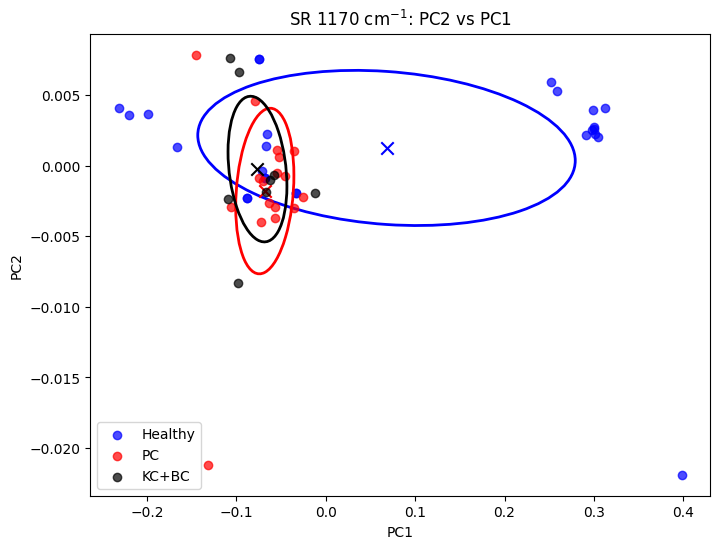

In [15]:
fig, ax = plt.subplots(figsize=(8,6))

for g, color, label in [(['Healthy'],'blue','Healthy'), (['PC'],'red','PC'), (['KC', 'BC'], 'black', 'KC+BC')]:
    sub = result_df[result_df['class'].isin(g)]
    print(sub.info())
    x = sub['SR_530_PC1'].values
    y = sub['SR_530_PC3'].values

    ax.scatter(x, y, color=color, alpha=0.7, label=label)
    draw_cov_ellipse(x, y, ax, color)
    ax.scatter(x.mean(), y.mean(), marker='x', color=color, s=80)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
ax.set_title('SR 1170 cm$^{-1}$: PC2 vs PC1')
plt.show()



In [16]:
result_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51 entries, 0 to 73
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   51 non-null     object 
 1   infoP        51 non-null     object 
 2   class        51 non-null     object 
 3   SR_1005_PC1  51 non-null     float64
 4   SR_1005_PC2  51 non-null     float64
 5   SR_1005_PC3  51 non-null     float64
 6   SR_1005_PC4  51 non-null     float64
 7   SR_530_PC1   51 non-null     float64
 8   SR_530_PC2   51 non-null     float64
 9   SR_530_PC3   51 non-null     float64
 10  SR_530_PC4   51 non-null     float64
 11  SR_1050_PC1  51 non-null     float64
 12  SR_1050_PC2  51 non-null     float64
 13  SR_1050_PC3  51 non-null     float64
 14  SR_1050_PC4  51 non-null     float64
 15  SR_1190_PC1  51 non-null     float64
 16  SR_1190_PC2  51 non-null     float64
 17  SR_1190_PC3  51 non-null     float64
 18  SR_1190_PC4  51 non-null     float64
 19  SR_1203_PC1  51

In [17]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Function to create 3D ellipsoid mesh
def get_ellipsoid_mesh(x, y, z, n_std=1.0, n_points=20):
    """
    x, y, z: arrays of points
    n_std: number of standard deviations for the ellipsoid
    n_points: mesh resolution
    """
    # Compute centroid and covariance
    data = np.vstack([x, y, z])
    cov = np.cov(data)
    mean = np.mean(data, axis=1)

    # Eigen decomposition (axes of ellipsoid)
    U, s, rotation = np.linalg.svd(cov)
    radii = n_std * np.sqrt(s)

    # Parametric angles
    u = np.linspace(0, 2 * np.pi, n_points)
    v = np.linspace(0, np.pi, n_points)
    u, v = np.meshgrid(u, v)

    # Parametric ellipsoid (unit sphere scaled by radii)
    X = radii[0] * np.cos(u) * np.sin(v)
    Y = radii[1] * np.sin(u) * np.sin(v)
    Z = radii[2] * np.cos(v)

    # Rotate and translate
    for i in range(len(X)):
        for j in range(len(X)):
            vec = rotation @ np.array([X[i, j], Y[i, j], Z[i, j]])
            X[i, j], Y[i, j], Z[i, j] = vec + mean

    return X, Y, Z

# Define groups
groups = [
    (['Healthy'], 'blue', 'Healthy'),
    (['PC'], 'red', 'PC'),
    (['KC', 'BC'], 'black', 'KC+BC')
]

fig = go.Figure()

for g, color, label in groups:
    sub = result_df[result_df['class'].isin(g)]
    
    x = sub['SR_1050_PC1'].values
    y = sub['SR_1050_PC2'].values
    z = sub['SR_1050_PC3'].values

    # Scatter all points
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(size=5, color=color, opacity=0.7),
        name=label,
        text=sub['patient_id'],
        hovertemplate='Patient: %{text}<br>PC1: %{x:.2f}<br>PC2: %{y:.2f}<br>PC3: %{z:.2f}<extra></extra>'
    ))

    # Scatter centroid
    fig.add_trace(go.Scatter3d(
        x=[x.mean()], y=[y.mean()], z=[z.mean()],
        mode='markers',
        marker=dict(size=10, color=color, symbol='x'),
        name=f'{label} centroid'
    ))

    # Ellipsoid mesh (1 std)
    Xs, Ys, Zs = get_ellipsoid_mesh(x, y, z, n_std=1)
    fig.add_trace(go.Surface(
        x=Xs, y=Ys, z=Zs,
        showscale=False,
        opacity=0.2,
        colorscale=[[0, color], [1, color]],
        name=f'{label} ellipsoid',
        hoverinfo='skip'
    ))

# Layout
fig.update_layout(
    title='SR 1170 cm$^{-1}$: PC1 vs PC2 vs PC3 with ellipsoids',
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    legend=dict(itemsizing='constant')
)

# Show in browser (best for VS Code)
import plotly.io as pio
pio.renderers.default = "browser"

fig.show()


In [18]:
# %matplotlib widget  # optional for matplotlib plots
import plotly.io as pio
pio.renderers.default = "notebook_connected"

pio.renderers.default = "browser"


import pandas as pd
import plotly.graph_objects as go

# Define groups
groups = [
    (['Healthy'], 'blue', 'Healthy'),
    (['PC'], 'red', 'PC'),
    (['KC', 'BC'], 'black', 'KC+BC')
]

fig = go.Figure()

for g, color, label in groups:
    sub = result_df[result_df['class'].isin(g)]
    
    # Scatter all points
    fig.add_trace(go.Scatter3d(
        x=sub['SR_1170_PC1'],
        y=sub['SR_1170_PC2'],
        z=sub['SR_1170_PC3'],
        mode='markers',
        marker=dict(size=5, color=color, opacity=0.7),
        name=label,
        text=sub['patient_id'],  # hover info
        hovertemplate='Patient: %{text}<br>PC1: %{x:.2f}<br>PC2: %{y:.2f}<br>PC3: %{z:.2f}<extra></extra>'
    ))
    
    # Scatter centroid
    fig.add_trace(go.Scatter3d(
        x=[sub['SR_1170_PC1'].mean()],
        y=[sub['SR_1170_PC2'].mean()],
        z=[sub['SR_1170_PC3'].mean()],
        mode='markers',
        marker=dict(size=10, color=color, symbol='x'),
        name=f'{label} centroid'
    ))

# Layout
fig.update_layout(
    title='SR 1170 cm$^{-1}$: PC1 vs PC2 vs PC3',
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    legend=dict(itemsizing='constant')
)

fig.show()


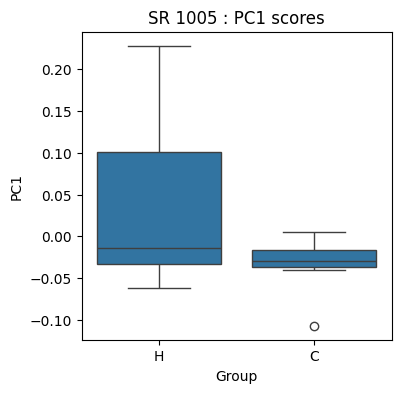

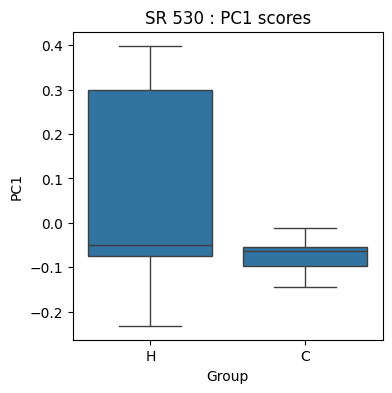

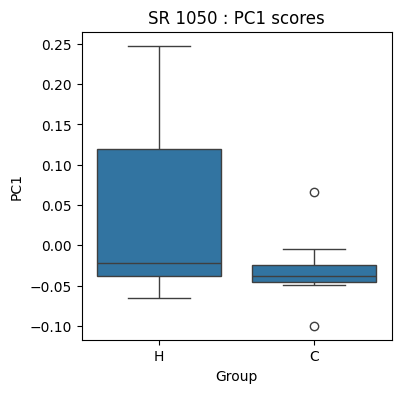

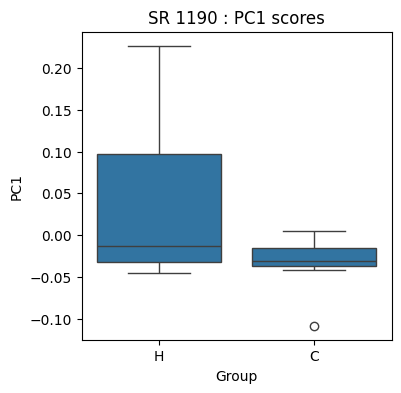

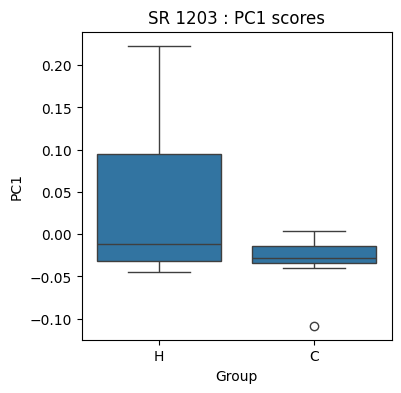

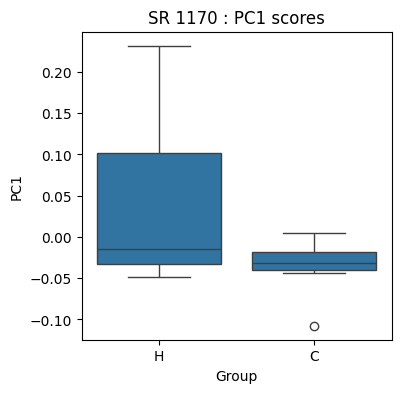

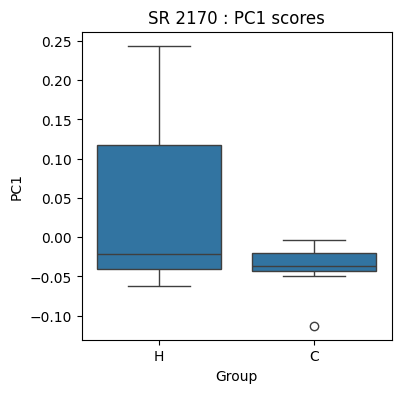

In [19]:
import seaborn as sns
result_df['y_binary'] = result_df['class'].apply(
    lambda x: "H" if x == "Healthy" else "C"
)
for y in SRlist:
    plt.figure(figsize=(4,4))
    sns.boxplot(
        x='y_binary',
        y=f'SR_{y}_PC1',
        data=result_df
    )
    plt.title(F'SR {y} : PC1 scores')
    plt.xlabel('Group')
    plt.ylabel('PC1')
    plt.show()


In [20]:
def extract_sr(df, wn_min, wn_max):
    X = []
    wns = None

    for _, row in df.iterrows():
        wn = row['wavenumber']
        inten = row['intensity_baseline_corrected']

        mask = (wn >= wn_min) & (wn <= wn_max)
        X.append(inten[mask])

        if wns is None:
            wns = wn[mask]

    return np.vstack(X), wns


In [21]:
X_sr1190, wn_sr1190 = extract_sr(df, 1170, 1210)
X_sr1190.shape

(51, 166)

In [22]:
labels = df['class'].astype(str).values  # '0' healthy, '1' cancer

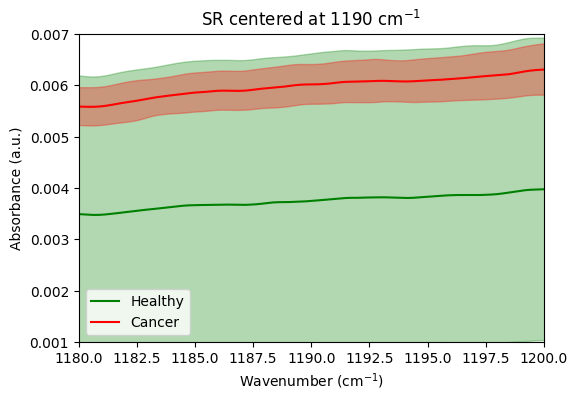

In [23]:
import matplotlib.pyplot as plt

X_h = X_sr1190[labels == 'H']
X_c = X_sr1190[labels == 'PC']

mean_h, std_h = X_h.mean(axis=0), X_h.std(axis=0)
mean_c, std_c = X_c.mean(axis=0), X_c.std(axis=0)

plt.figure(figsize=(6,4))
plt.plot(wn_sr1190, mean_h, label='Healthy', color='green')
plt.fill_between(wn_sr1190, mean_h-std_h, mean_h+std_h,
                 color='green', alpha=0.3)

plt.plot(wn_sr1190, mean_c, label='Cancer', color='red')
plt.fill_between(wn_sr1190, mean_c-std_c, mean_c+std_c,
                 color='red', alpha=0.3)

plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel('Absorbance (a.u.)')
plt.ylim(0.001, 0.007)
plt.xlim(1180, 1200)
plt.title('SR centered at 1190 cm$^{-1}$')
plt.legend()
plt.show()


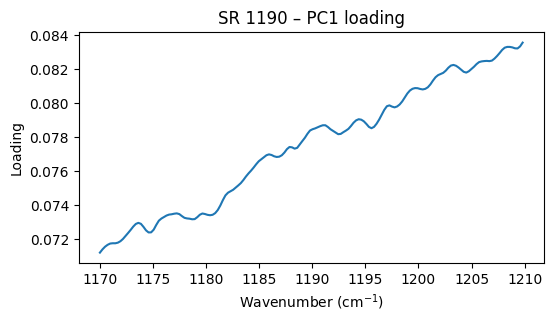

In [24]:
from sklearn.decomposition import PCA

X_centered = X_sr1190 - X_sr1190.mean(axis=0)

pca = PCA(n_components=4)
scores = pca.fit_transform(X_centered)

plt.figure(figsize=(6,3))
plt.plot(wn_sr1190, pca.components_[0])
plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel('Loading')
plt.title('SR 1190 – PC1 loading')
plt.show()


In [25]:
np.corrcoef(scores[:,0], result_df['SR_1190_PC1'])[0,1]

np.float64(-0.8915995506685334)

## Binary Classification 

In [26]:
df_to_use = result_df[result_df["class"].isin(["Healthy", "PC"])]

df_to_use['y_binary'] = df_to_use['class'].apply(
    lambda x: 0 if x == "Healthy" else 1
)

/tmp/ipykernel_8538/2966948202.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [27]:
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

def svm_loocv_decision_plot_weighted_multi(df, pcs, c=1, y_col="y_binary"):
    X = df[pcs].values
    y = df[y_col].values

    svm = SVC(kernel="linear", C=c, class_weight="balanced")
    # svm = SVC(kernel="linear", C=c)

    loo = LeaveOneOut()

    decisions = []
    true_labels = []

    for train, test in loo.split(X):
        svm.fit(X[train], y[train])
        decisions.append(svm.decision_function(X[test])[0])
        true_labels.append(y[test][0])

    decisions = np.array(decisions)
    true_labels = np.array(true_labels)

    # Auto-flip if SVM chose the opposite orientation
    if decisions[true_labels == 0].mean() > decisions[true_labels == 1].mean():
        decisions = -decisions

    # Compute predicted labels
    y_pred = (decisions > 0).astype(int)

    # Confusion matrix and metrics
    cm = confusion_matrix(true_labels, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = (tp + tn) / len(true_labels)

    # Mean decision values per class
    mean_healthy = decisions[true_labels == 0].mean()
    mean_cancer = decisions[true_labels == 1].mean()

    metrics = {
        "confusion_matrix": cm,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "accuracy": accuracy,
        "balanced_accuracy": (sensitivity+specificity)/2,
        "mean_decision_healthy": mean_healthy,
        "mean_decision_cancer": mean_cancer,
        "y_pred": y_pred,
        "decisions": decisions,
        "true_labels": true_labels
    }

    return metrics

def plot_decision_values(decisions, labels):
    plt.figure(figsize=(6,4))
    for i, (d, l) in enumerate(zip(decisions, labels)):
        color = "red" if l == 1 else "blue"
        plt.scatter(i, d, color=color)
    plt.axhline(0, linestyle="--", color="black")
    plt.axhspan(-0.2, 0.2, color="gray", alpha=0.3)
    plt.ylabel("SVM decision value")
    plt.xlabel("Sample index")
    plt.title("LOOCV SVM decision values")
    plt.show()


['SR_2170_PC1', 'SR_1170_PC1', 'SR_1190_PC1', 'SR_1050_PC1', 'SR_1203_PC1', 'SR_1005_PC1', 'SR_530_PC1', 'SR_1050_PC4']
Confusion matrix:
 [[26  0]
 [17  0]]
Sensitivity: 0.00
Specificity: 1.00
Balanced Accuracy: 0.50
Accuracy: 0.60
Mean decision (Healthy): -0.76
Mean decision (Cancer): -0.69


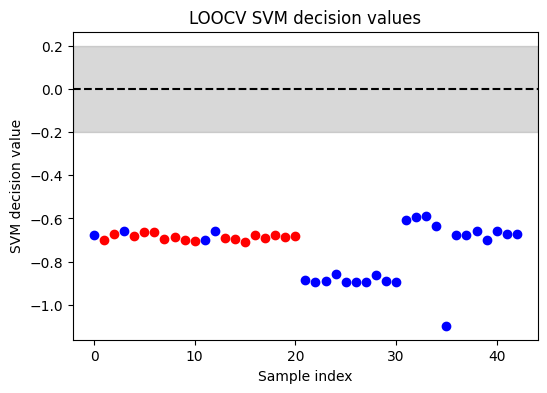

In [28]:
num = range(len(SRlist))
# pcs_to_use = [f"SR_{SRlist[n-1]}_PC{1}" for n in num] + ["SR_1050_PC4"]
pcs_to_use = ['SR_2170_PC1','SR_1170_PC1', 'SR_1190_PC1', 'SR_1050_PC1', 'SR_1203_PC1', 'SR_1005_PC1', 'SR_530_PC1'] + ['SR_1050_PC4']
# pcs_to_use = ['SR_2170_PC1']

# pcs_to_use += [f"SR_{SRlist[n-1]}_PC{2}" for n in num]
# pcs_to_use += [f"SR_{SRlist[n-1]}_PC{3}" for n in num]
# pcs_to_use += [f"SR_{SRlist[n-1]}_PC{4}" for n in num]


print(pcs_to_use)
metrics = svm_loocv_decision_plot_weighted_multi(df_to_use, pcs_to_use, c= 0.1)

print("Confusion matrix:\n", metrics["confusion_matrix"])
print(f"Sensitivity: {metrics['sensitivity']:.2f}")
print(f"Specificity: {metrics['specificity']:.2f}")
print(f"Balanced Accuracy: {metrics['balanced_accuracy']:.2f}")
print(f"Accuracy: {metrics['accuracy']:.2f}")
print(f"Mean decision (Healthy): {metrics['mean_decision_healthy']:.2f}")
print(f"Mean decision (Cancer): {metrics['mean_decision_cancer']:.2f}")

plot_decision_values(metrics["decisions"], metrics["true_labels"])


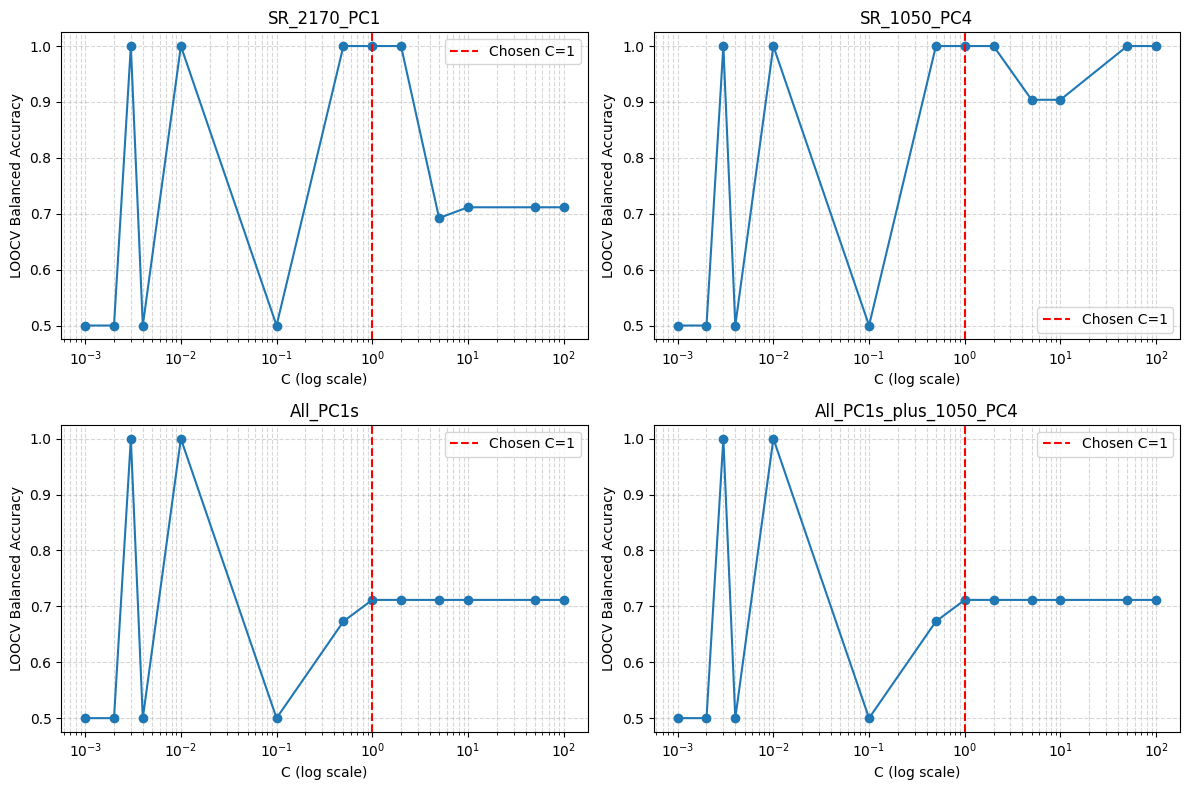

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Define 4 SR/PC sets for the plots
SR_pc_sets = {
    "SR_2170_PC1": ["SR_2170_PC1"],
    "SR_1050_PC4": ["SR_1050_PC4"],
    "All_PC1s": ['SR_2170_PC1', 'SR_1170_PC1', 'SR_1190_PC1', 'SR_1050_PC1', 
                 'SR_1203_PC1', 'SR_1005_PC1', 'SR_530_PC1'],
    "All_PC1s_plus_1050_PC4": ['SR_2170_PC1', 'SR_1170_PC1', 'SR_1190_PC1', 'SR_1050_PC1',
                                'SR_1203_PC1', 'SR_1005_PC1', 'SR_530_PC1', 'SR_1050_PC4']
}

# Range of C values to test
C_values = [0.001, 0.002, 0.003, 0.004, 0.010, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
# C_values = np.arange(0.001, 100, 0.1)
# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # easier indexing

for i, (label, pcs_to_use) in enumerate(SR_pc_sets.items()):
    bal_acc_list = []
    for C in C_values:
        metrics = svm_loocv_decision_plot_weighted_multi(
            df_to_use,   # your dataframe
            pcs_to_use, 
            c=C
        )
        bal_acc_list.append(metrics["balanced_accuracy"])
    
    bal_acc_array = np.array(bal_acc_list)
    
    ax = axes[i]
    ax.plot(C_values, bal_acc_array, marker='o', linestyle='-', color='tab:blue')
    ax.set_xscale('log')
    ax.set_xlabel('C (log scale)')
    ax.set_ylabel('LOOCV Balanced Accuracy')
    ax.set_title(label)
    ax.grid(True, which='both', ls='--', alpha=0.5)
    ax.axvline(1, color='red', linestyle='--', label='Chosen C=1')
    ax.legend()

plt.tight_layout()
plt.show()



Cohen’s d answers the right question:

“Is the disease effect large relative to biological variability?”

Not:

“Can I classify every individual perfectly?”

In [30]:
import numpy as np

def cohens_d(x0, x1):
    n0, n1 = len(x0), len(x1)
    mu0, mu1 = np.mean(x0), np.mean(x1)
    s0, s1 = np.std(x0, ddof=1), np.std(x1, ddof=1)

    sp = np.sqrt(((n0 - 1)*s0**2 + (n1 - 1)*s1**2) / (n0 + n1 - 2))
    d = (mu1 - mu0) / sp
    return d

# pcs_to_use = "SR_1190_PC1"
for sr in SRlist:
        for n in [1,2,3,4]:
            pc = f"SR_{sr}_PC{n}"
            x_healthy = df_to_use[df_to_use.y_binary == 0][pc].values
            x_cancer  = df_to_use[df_to_use.y_binary == 1][pc].values
            
            d = cohens_d(x_healthy, x_cancer)
            print(f"Cohen's d for {pc}: {d:.3f}")
        print("                                       ")


Cohen's d for SR_1005_PC1: -0.827
Cohen's d for SR_1005_PC2: 0.028
Cohen's d for SR_1005_PC3: 0.079
Cohen's d for SR_1005_PC4: -0.004
                                       
Cohen's d for SR_530_PC1: -0.820
Cohen's d for SR_530_PC2: 0.410
Cohen's d for SR_530_PC3: -0.541
Cohen's d for SR_530_PC4: -0.193
                                       
Cohen's d for SR_1050_PC1: -0.815
Cohen's d for SR_1050_PC2: -0.377
Cohen's d for SR_1050_PC3: -0.348
Cohen's d for SR_1050_PC4: -0.872
                                       
Cohen's d for SR_1190_PC1: -0.910
Cohen's d for SR_1190_PC2: 0.352
Cohen's d for SR_1190_PC3: 0.391
Cohen's d for SR_1190_PC4: 0.114
                                       
Cohen's d for SR_1203_PC1: -0.902
Cohen's d for SR_1203_PC2: 0.411
Cohen's d for SR_1203_PC3: -0.053
Cohen's d for SR_1203_PC4: 0.375
                                       
Cohen's d for SR_1170_PC1: -0.921
Cohen's d for SR_1170_PC2: 0.635
Cohen's d for SR_1170_PC3: -0.018
Cohen's d for SR_1170_PC4: -0.4

In [31]:
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut

def loocv_accuracy(X, y, C=1, balanced=True):
    svm = SVC(
        kernel="linear",
        C=C,
        class_weight="balanced" if balanced else None
    )
    loo = LeaveOneOut()

    correct = 0
    for train, test in loo.split(X):
        svm.fit(X[train], y[train])
        pred = svm.predict(X[test])[0]
        correct += (pred == y[test][0])

    return correct / len(y)

pcs = []
for sr in SRlist:
        for n in [1,2,3]:
            pcs.append(f"SR_{sr}_PC{n}")
X = df_to_use[pcs].values
y = df_to_use.y_binary.values

real_acc = loocv_accuracy(X, y)

n_perm = 1000
perm_accs = []

for _ in range(n_perm):
    y_perm = np.random.permutation(y)
    acc = loocv_accuracy(X, y_perm)
    perm_accs.append(acc)

perm_accs = np.array(perm_accs)
p_value = np.mean(perm_accs >= real_acc)

print(f"Real accuracy: {real_acc:.3f}")
print(f"Permutation p-value: {p_value:.4f}")
print(np.mean(perm_accs))


Real accuracy: 0.651
Permutation p-value: 0.0640
0.19911627906976748


In [32]:
np.histogram_bin_edges(perm_accs)

array([0.        , 0.07209302, 0.14418605, 0.21627907, 0.28837209,
       0.36046512, 0.43255814, 0.50465116, 0.57674419, 0.64883721,
       0.72093023])

In [33]:
import numpy as np
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt

def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)

    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=theta,
        **kwargs
    )
    ax.add_patch(ellipse)


/tmp/ipykernel_8538/162978565.py:51: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



TypeError: 'YAxis' object is not callable

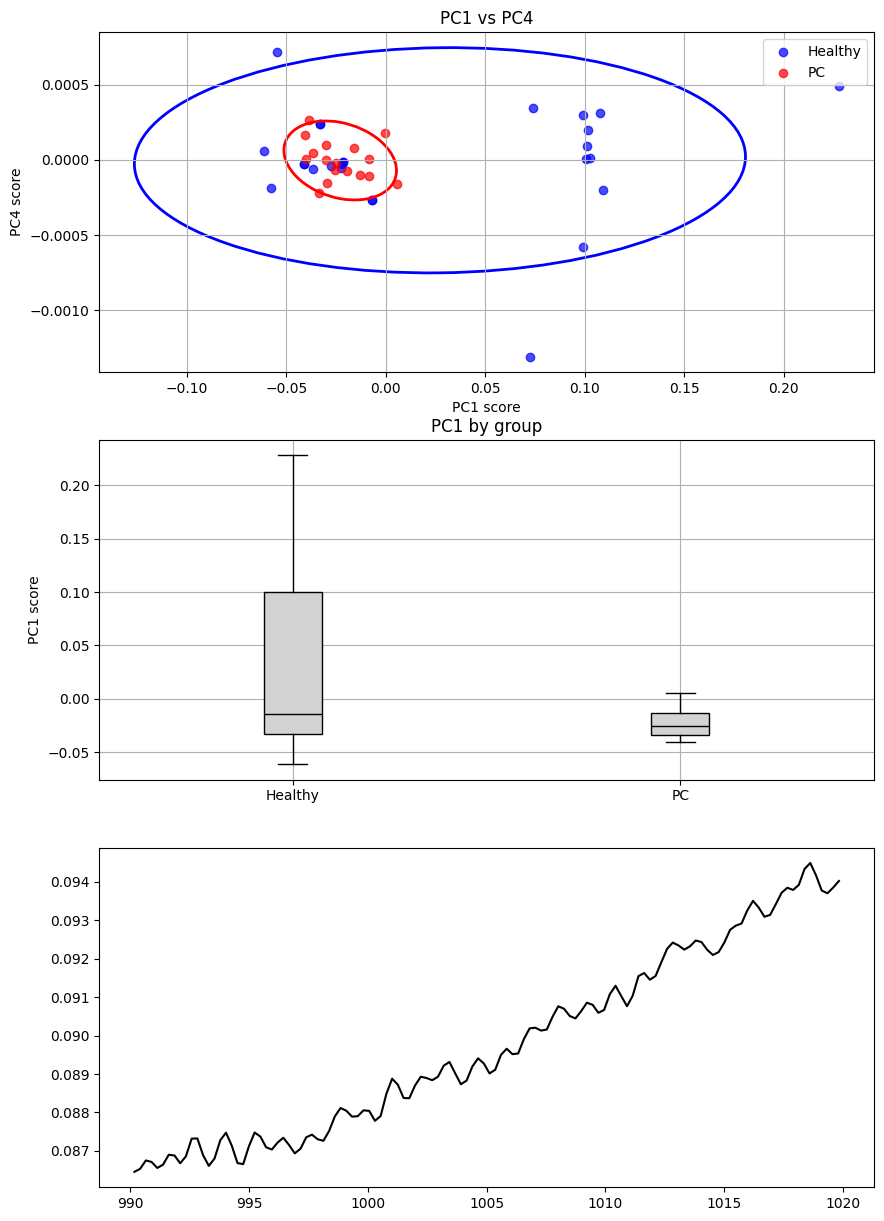

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# ===== 1. Prepare data =====
X = SR_matrices["SR_1005"]
Xc = X - X.mean(axis=0)

pca = PCA(n_components=4)
scores = pca.fit_transform(Xc)
loadings = pca.components_

pc1 = scores[:, 0]
pc4 = scores[:, 3]

labels = result_df["class"].values
groups = ["Healthy", "PC"]

X_sr1005, wn = extract_sr(df, 990, 1020)


# ===== 2. Figure layout =====
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# --------------------------------------------------
# LEFT: PC1 vs PC4 with ellipses
# --------------------------------------------------
ax = axes[0]

for g, color in zip(groups, ["blue", "red"]):
    idx = labels == g
    ax.scatter(pc1[idx], pc4[idx], label=g, alpha=0.7, color=color)
    confidence_ellipse(
        pc1[idx], pc4[idx], ax,
        edgecolor=color, facecolor="none", linewidth=2
    )

ax.set_xlabel("PC1 score")
ax.set_ylabel("PC4 score")
ax.set_title("PC1 vs PC4")
ax.legend()
ax.grid(True)

# --------------------------------------------------
# CENTER: Boxplot of PC1
# --------------------------------------------------
ax = axes[1]

data = [pc1[labels == g] for g in groups]

ax.boxplot(
    data,
    labels=groups,
    patch_artist=True,
    boxprops=dict(facecolor="lightgray"),
    medianprops=dict(color="black")
)

ax.set_ylabel("PC1 score")
ax.set_title("PC1 by group")
ax.grid(True)

# --------------------------------------------------
# RIGHT: PC1 loading vector
# --------------------------------------------------
ax = axes[2]

ax.plot(wn, loadings[0], color="black")
# ax.plot(wn, X_sr1005[1], color="red")
ax.yaxis(0.05, 0.1)
ax.axhline(0, linestyle="--", color="gray")

ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Loading weight")
# ax.legend()
ax.set_title("PC1 loading")

# --------------------------------------------------
# Save
# --------------------------------------------------
plt.tight_layout()
plt.show()


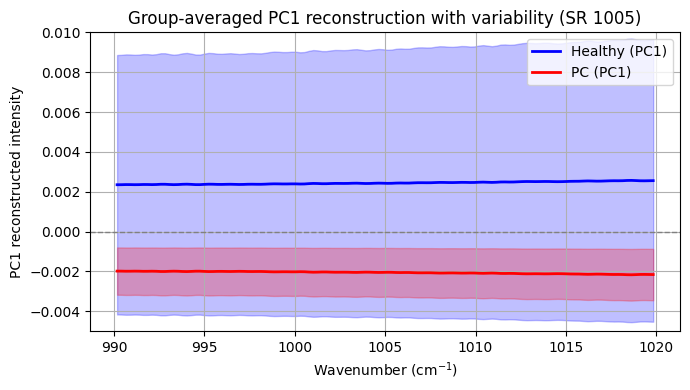

In [35]:
pc1_scores = scores[:, 0]
pc1_loading = loadings[0]

# Shape: (n_samples, n_wavenumbers)
X_pc1 = np.outer(pc1_scores, pc1_loading)

labels = result_df["class"].values

X_pc1_healthy = X_pc1[labels == "Healthy"]
X_pc1_cancer  = X_pc1[labels == "PC"]

mean_h = X_pc1_healthy.mean(axis=0)
std_h  = X_pc1_healthy.std(axis=0)

mean_c = X_pc1_cancer.mean(axis=0)
std_c  = X_pc1_cancer.std(axis=0)

plt.figure(figsize=(7, 4))

# Healthy
plt.plot(
    wn, mean_h,
    color="blue", linewidth=2, label="Healthy (PC1)"
)
plt.fill_between(
    wn,
    mean_h - std_h,
    mean_h + std_h,
    color="blue", alpha=0.25
)

# Cancer
plt.plot(
    wn, mean_c,
    color="red", linewidth=2, label="PC (PC1)"
)
plt.fill_between(
    wn,
    mean_c - std_c,
    mean_c + std_c,
    color="red", alpha=0.25
)

plt.axhline(0, linestyle="--", color="gray", linewidth=1)

plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("PC1 reconstructed intensity")
plt.title("Group-averaged PC1 reconstruction with variability (SR 1005)")
plt.ylim(-0.005, 0.010)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## k fold cross validation
Perform PCA + ANOVA inside each fold.

## Functional SVM on the entire spectrum

In [36]:
df["class"].value_counts()

class
H     26
PC    17
BC     5
KC     3
Name: count, dtype: int64

In [37]:
from sklearn.svm import SVC

In [ ]:
def fsvm_loocv(
    X_full,
    y,
    n_fpcs=5,
    C=1.0,
    kernel="linear"
):
    """
    Functional SVM using FPCA inside each LOOCV fold
    (faithful to Xie & Ogden, 2024)

    Parameters
    ----------
    X_full : ndarray (n_samples, n_wavenumbers)
        Discretized functional data (spectra)
    y : ndarray (n_samples,)
        Binary labels (0/1)
    n_fpcs : int
        Number of functional principal components
    C : float
        SVM regularization parameter
    kernel : str
        'linear' or 'rbf'

    Returns
    -------
    results : dict
    """


    loo = LeaveOneOut()

    decisions = []
    true_labels = []

    for train_idx, test_idx in loo.split(X_full):

        # ---- Split data ----
        X_train = X_full[train_idx]
        X_test  = X_full[test_idx]
        y_train = y[train_idx]
        y_test  = y[test_idx]

        # ---- Mean-centering (functional centering) ----
        mean_spectrum = X_train.mean(axis=0)
        X_train_c = X_train - mean_spectrum
        X_test_c  = X_test  - mean_spectrum

        # Represent spectrum as smooth function using chosen basis (here PCA scores)
        # ---- FPCA (PCA on discretized functions) ----
        pca = PCA(n_components=n_fpcs, svd_solver="full")
        scores_train = pca.fit_transform(X_train_c)
        scores_test  = pca.transform(X_test_c)

        # ---- Train SVM on FPCA scores ----
        svm = SVC(kernel=kernel, C=C)
        svm.fit(scores_train, y_train)

        # ---- Decision value ----
        decision = svm.decision_function(scores_test)[0]

        decisions.append(decision)
        true_labels.append(y_test[0])

    decisions = np.array(decisions)
    true_labels = np.array(true_labels)

    # ---- Orientation correction ----
    if decisions[true_labels == 0].mean() > decisions[true_labels == 1].mean():
        decisions *= -1

    # ---- Predictions ----
    y_pred = (decisions > 0).astype(int)

    # ---- Metrics ----
    cm = confusion_matrix(true_labels, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = (tp + tn) / len(y)

    return {
        "confusion_matrix": cm,
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "balanced_accuracy": 0.5 * (sensitivity + specificity),
        "decisions": decisions,
        "true_labels": true_labels,
        "y_pred": y_pred
    }


In [39]:
def plot_fsvm_decisions(results):
    decisions = results["decisions"]
    labels = results["true_labels"]

    plt.figure(figsize=(7,4))
    plt.scatter(
        np.where(labels == 0),
        decisions[labels == 0],
        label="Healthy",
        alpha=0.7
    )
    plt.scatter(
        np.where(labels == 1),
        decisions[labels == 1],
        label="Disease",
        alpha=0.7
    )

    plt.axhline(0, color="black", linestyle="--")
    plt.axhspan(-0.2, 0.2, color="gray", alpha=0.2, label="Gray zone")

    plt.xlabel("Sample index (LOOCV)")
    plt.ylabel("Decision value")
    plt.title("FSVM LOOCV Decision Values")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [40]:
import numpy as np

# Check equal spectrum lengths
lengths = df["spectrum_length"].values
assert len(set(lengths)) == 1, "Spectra have unequal lengths!"

p = lengths[0]
n = df.shape[0]

print(f"n_samples = {n}, n_wavenumbers = {p}")

# Wavenumber grid (shared across all samples)
wavenumbers = np.array(df.iloc[0]["wavenumber"])

# Stack intensities row-wise: (n_samples, n_wavenumbers)
X_full = np.vstack(
    df["intensity_baseline_corrected"].apply(np.array).values
)

print(X_full.shape)  # should be (51, p)

# Keep only H and PC
mask = df["class"].isin(["H", "PC"])

X_full = X_full[mask.values]
y = df.loc[mask, "class"].map({"H": 0, "PC": 1}).values

print("Class counts:", np.bincount(y))
print("X_full shape:", X_full.shape)



n_samples = 51, n_wavenumbers = 14517
(51, 14517)
Class counts: [26 17]
X_full shape: (43, 14517)


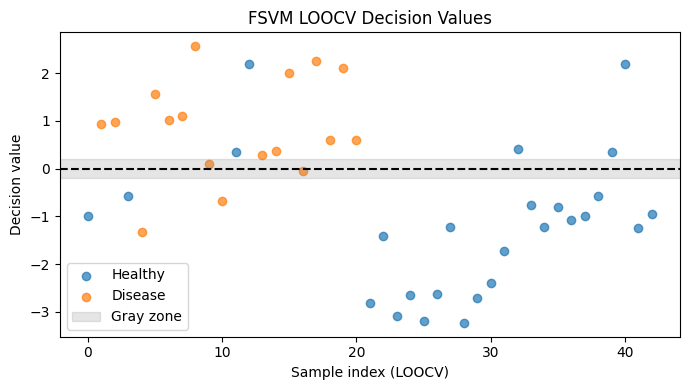

In [41]:
results = fsvm_loocv(X_full, y, n_fpcs=5,C=0.7)
plot_fsvm_decisions(results)

In [42]:
results

{'confusion_matrix': array([[21,  5],
        [ 3, 14]]),
 'accuracy': np.float64(0.813953488372093),
 'sensitivity': np.float64(0.8235294117647058),
 'specificity': np.float64(0.8076923076923077),
 'balanced_accuracy': np.float64(0.8156108597285068),
 'decisions': array([-0.99969594,  0.93717463,  0.97755098, -0.58389577, -1.32457423,
         1.56830616,  1.02897391,  1.09893285,  2.56593709,  0.0926714 ,
        -0.67085541,  0.3584284 ,  2.18567628,  0.29036764,  0.3710215 ,
         1.99867251, -0.05647007,  2.25715951,  0.6079049 ,  2.10074921,
         0.59447837, -2.82205874, -1.40849083, -3.09762643, -2.65370686,
        -3.19022156, -2.63182403, -1.22377124, -3.2324463 , -2.70719595,
        -2.40291707, -1.73128097,  0.41561047, -0.76349701, -1.23317672,
        -0.81349125, -1.08039652, -0.99969594, -0.58389577,  0.3584284 ,
         2.18567628, -1.23568839, -0.95411191]),
 'true_labels': array([0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
        0, 0,

In [55]:
def extract_spectral_region(X, wavenumbers, center, half_width=15):
    """
    Extract spectral region [center - half_width, center + half_width]
    """
    mask = (wavenumbers >= center - half_width) & \
           (wavenumbers <= center + half_width)

    X_region = X[:, mask]
    wn_region = wavenumbers[mask]

    return X_region, wn_region



(43, 166)


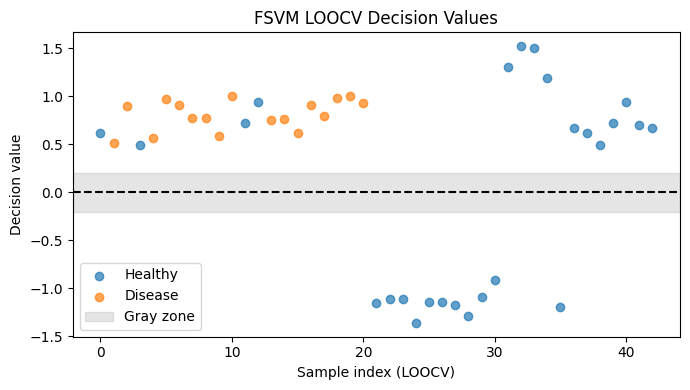

{'confusion_matrix': array([[11, 15],
       [ 0, 17]]), 'accuracy': np.float64(0.6511627906976745), 'sensitivity': np.float64(1.0), 'specificity': np.float64(0.4230769230769231), 'balanced_accuracy': np.float64(0.7115384615384616), 'decisions': array([ 0.6206929 ,  0.50924955,  0.89685908,  0.49278032,  0.56857774,
        0.96621662,  0.91181999,  0.77126058,  0.77603922,  0.58494693,
        0.99727462,  0.72432353,  0.93647012,  0.74919089,  0.76571705,
        0.61425513,  0.91319509,  0.79594064,  0.98173844,  1.00040717,
        0.92939485, -1.15111931, -1.10498452, -1.11488062, -1.35862132,
       -1.13742478, -1.14431205, -1.17756252, -1.28315249, -1.09101928,
       -0.91256191,  1.30898787,  1.52094818,  1.50398816,  1.19376239,
       -1.19179865,  0.66917844,  0.6206929 ,  0.49278032,  0.72432353,
        0.93647012,  0.69789679,  0.6685877 ]), 'true_labels': array([0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [79]:
center = 1190

X_sr, wn_sr = extract_spectral_region(
    X_full,
    wavenumbers,
    center=center,
    half_width=20
)

print(X_sr.shape)
y_sr = y  # identical reference
assert X_sr.shape[0] == len(y)
assert X_sr.shape[1] == len(wn_sr)

results = fsvm_loocv(X_sr, y_sr, n_fpcs=5,C=1500)
plot_fsvm_decisions(results)
print(results)



In [63]:
y

array([0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [64]:
X_sr

array([[-0.02454615, -0.02427215, -0.02437215, ..., -0.00752215,
        -0.00670215, -0.00658215],
       [-0.02578605, -0.02580405, -0.02566205, ..., -0.00717205,
        -0.00647805, -0.00624805],
       [-0.0261428 , -0.0265108 , -0.0268468 , ..., -0.0061688 ,
        -0.0048708 , -0.0044368 ],
       ...,
       [-0.02516106, -0.02572906, -0.02589106, ..., -0.00438906,
        -0.00320906, -0.00294506],
       [-0.02328317, -0.02350717, -0.02376917, ..., -0.00581917,
        -0.00495317, -0.00474117],
       [-0.02364503, -0.02373503, -0.02387103, ..., -0.00619503,
        -0.00541303, -0.00515903]], shape=(43, 124))

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51 entries, 0 to 73
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   patient_id                    51 non-null     object
 1   original_filename             51 non-null     object
 2   category                      51 non-null     object
 3   normVP                        51 non-null     int64 
 4   infoP                         51 non-null     object
 5   wavenumber                    51 non-null     object
 6   intensity                     51 non-null     object
 7   spectrum_length               51 non-null     int64 
 8   intensity_baseline_corrected  51 non-null     object
 9   class                         51 non-null     object
dtypes: int64(2), object(8)
memory usage: 4.4+ KB


In [81]:
result_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51 entries, 0 to 73
Data columns (total 32 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   51 non-null     object 
 1   infoP        51 non-null     object 
 2   class        51 non-null     object 
 3   SR_1005_PC1  51 non-null     float64
 4   SR_1005_PC2  51 non-null     float64
 5   SR_1005_PC3  51 non-null     float64
 6   SR_1005_PC4  51 non-null     float64
 7   SR_530_PC1   51 non-null     float64
 8   SR_530_PC2   51 non-null     float64
 9   SR_530_PC3   51 non-null     float64
 10  SR_530_PC4   51 non-null     float64
 11  SR_1050_PC1  51 non-null     float64
 12  SR_1050_PC2  51 non-null     float64
 13  SR_1050_PC3  51 non-null     float64
 14  SR_1050_PC4  51 non-null     float64
 15  SR_1190_PC1  51 non-null     float64
 16  SR_1190_PC2  51 non-null     float64
 17  SR_1190_PC3  51 non-null     float64
 18  SR_1190_PC4  51 non-null     float64
 19  SR_1203_PC1  51